Goal of this notebook is to 1) have subsurface figures in one place, and 2) add some new figures to define "responsive layer"

In [2]:
import numpy as np
import matplotlib.pyplot as plt
from netCDF4 import Dataset
from scipy import interpolate
import scipy.signal
from datetime import datetime as dt
import cmocean
import datetime
from matplotlib.dates import DateFormatter
import glob
from matplotlib.cm import ScalarMappable
from matplotlib.colors import Normalize
import matplotlib as mpl
import matplotlib.dates as mdates
from scipy.optimize import curve_fit
import pandas as pd
import csv
myFmt = mdates.DateFormatter('%m-%d')

from ICECAPS_support_functions import *

In [8]:
fversion = 'v4.2_20250730_sfcdif+4.0_ksi15.0'

simba_data = open_corrected_simba_temps(fversion)

simba_temps = simba_data['temperature']
simba_dates = simba_data['dates']
simba_depths = simba_data['height']
simba_sfc = simba_data['snow_surface']

simba_seconds = datetimes_to_seconds(simba_dates)

depth_rel_sfc, temps_rel_sfc = make_temps_rel_to_sfc(simba_depths, simba_temps, simba_sfc)
dTdz_rel_sfc =  np.gradient(temps_rel_sfc, depth_rel_sfc, axis=1)

avg_diurnal_dTdz = get_diurnal_cycle(simba_dates, dTdz_rel_sfc)
avg_diurnal_T = get_diurnal_cycle(simba_dates, temps_rel_sfc)
std_diurnal_T = get_diurnal_cycle(simba_dates, temps_rel_sfc, stat='std')

plt_tod = get_simba_time_of_day(simba_dates)

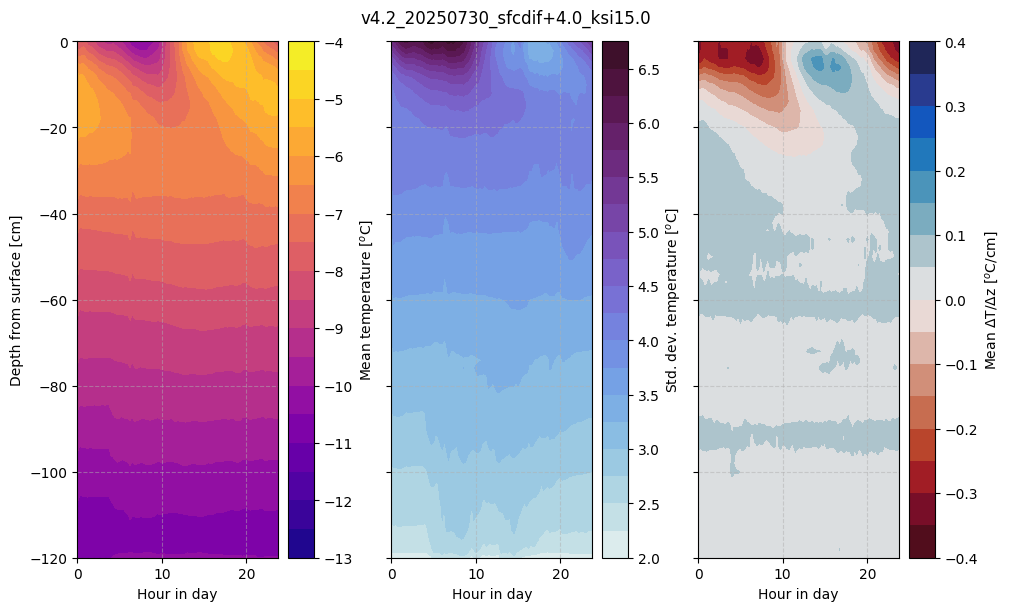

In [6]:
fig, axs = plt.subplots(1,3, figsize=(10,6), constrained_layout=True, sharey=True)

cbar_labels = ['Mean temperature [$^o$C]', 'Std. dev. temperature [$^o$C]', 'Mean $\Delta$T/$\Delta$z [$^o$C/cm]']
levels = [np.arange(-13,-3.6,.5), np.arange(2,7,.25), np.arange(-.4,.41,.05)]
cmaps = [plt.cm.plasma, cmocean.cm.dense, cmocean.cm.balance_r]

for i, (ax, var) in enumerate(zip(axs.ravel(), [avg_diurnal_T, std_diurnal_T, avg_diurnal_dTdz])):
    cb = ax.contourf(np.unique(plt_tod), depth_rel_sfc, np.swapaxes(var,0,1), levels=levels[i], cmap=cmaps[i])
    plt.colorbar(cb, label=cbar_labels[i], ax=ax)

    ax.set_ylim(-120,0)
    
    ax.set_xlabel('Hour in day')
    ax.grid(alpha=.5, ls='--')

axs[0].set_ylabel('Depth from surface [cm]')
fig.suptitle(fversion)
plt.show()

### defining responsive layer: running std devation with depth

In [13]:
# simba_temps = simba_data['temperature']
# simba_dates = simba_data['dates']
# simba_depths = simba_data['height']
# simba_sfc = simba_data['snow_surface']

# simba_seconds = datetimes_to_seconds(simba_dates)

simba_dTdz = np.gradient(simba_temps, simba_depths, axis=1)
simba_dTdt = np.gradient(simba_temps, simba_seconds, axis=0)

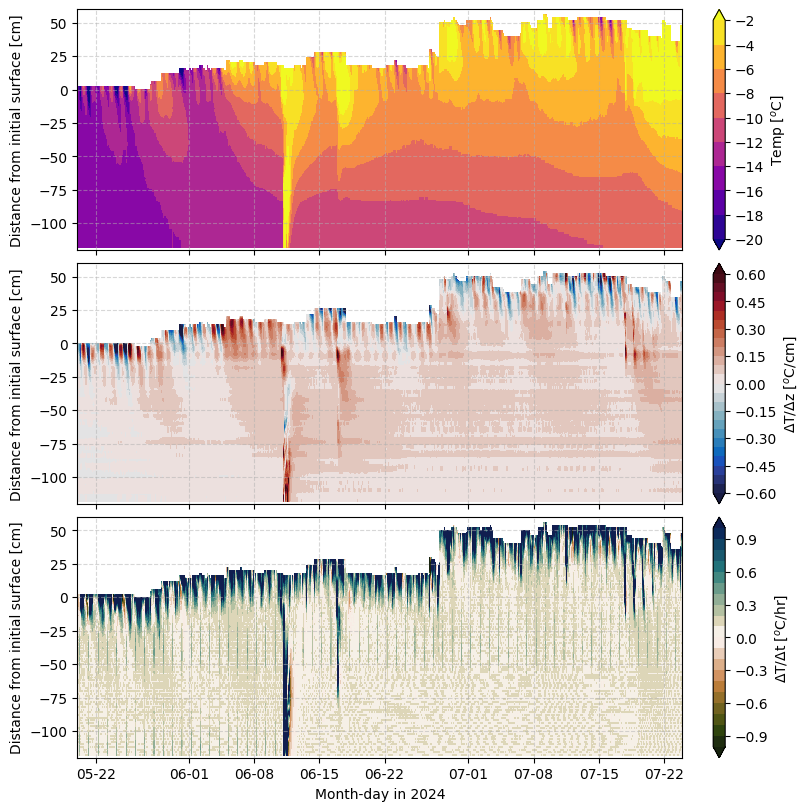

In [49]:
fig, axs = plt.subplots(3, figsize=(8,8), sharey=True, sharex=True, constrained_layout=True)

plt_vars = [simba_temps, simba_dTdz, simba_dTdt*60.*60.]
plt_labels = ['Temp [$^o$C]', '$\Delta$T/$\Delta$z [$^o$C/cm]', '$\Delta$T/$\Delta$t [$^o$C/hr]']
plt_cmaps = [plt.cm.plasma, cmocean.cm.balance, cmocean.cm.tarn]
plt_levs = [np.arange(-20,0,2), np.arange(-.6,.61,.05), np.arange(-1,1.1,.1)]


for i, ax in enumerate(axs.ravel()):
    cb = ax.contourf(simba_dates, simba_depths, np.swapaxes(plt_vars[i],0,1), cmap=plt_cmaps[i], levels=plt_levs[i],
                    extend='both')
    plt.colorbar(cb, ax=ax, label=plt_labels[i])
    
    ax.grid(alpha=.5, ls='--')
    ax.set_ylabel('Distance from initial surface [cm]')

    ax.xaxis.set_major_formatter(myFmt)

axs[0].set_ylim(-120,60)
axs[-1].set_xlabel('Month-day in 2024')
plt.show()

Want running standard deviation - relative to surface and simba?

In [23]:
# depth_rel_sfc
# temps_rel_sfc
# dTdz_rel_sfc


def calc_running_stdev(data_in, window=4*24):
    """ window is the window length in time steps, so 4 observations for 24 hours
    """
        
    for i in range(data_in.shape[0]):

        try:
            time_step_var = np.ma.var(np.ma.masked_invalid(data_in.copy()[i-int(window/2):i+int(window/2)+1,:]), axis=0)
        except:
            time_step_var = np.full(var.shape[0], -999)

        if i==0:
            rolling_var_from_vert_win = time_step_var[np.newaxis,:]
        else:
            rolling_var_from_vert_win = np.ma.concatenate((rolling_var_from_vert_win, time_step_var[np.newaxis,:]))
            
    
    return rolling_var_from_vert_win

#### Relative to SIMBA

In [51]:
temps_std_24 = calc_running_stdev(simba_temps, window=4*24)
dTdz_std_24 = calc_running_stdev(simba_dTdz, window=4*24)

temps_std_48 = calc_running_stdev(simba_temps, window=4*48)
dTdz_std_48 = calc_running_stdev(simba_dTdz, window=4*48)

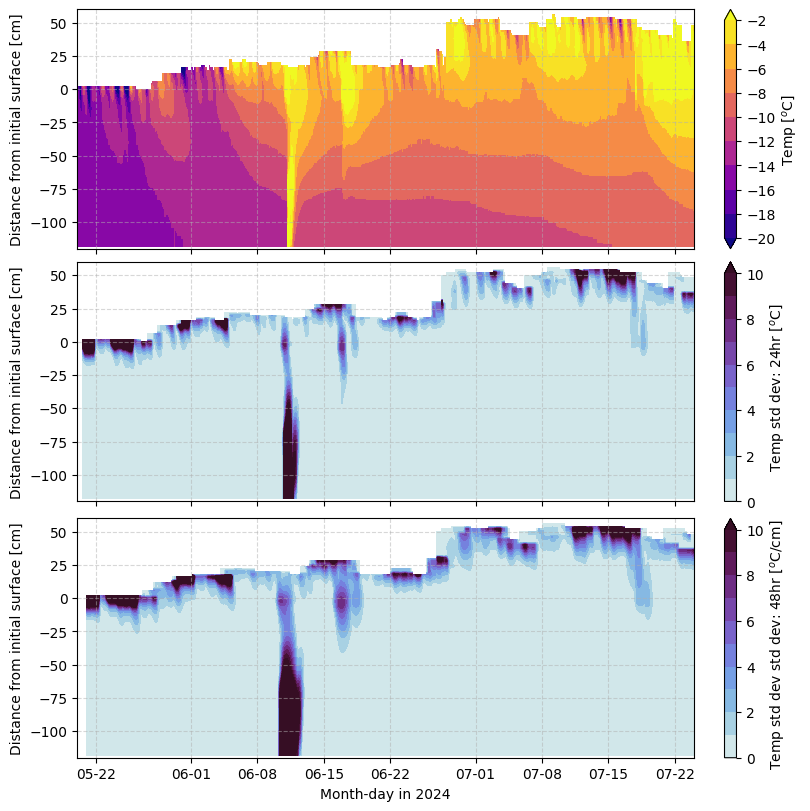

In [55]:
fig, axs = plt.subplots(3, figsize=(8,8), sharey=True, sharex=True, constrained_layout=True)

plt_vars = [simba_temps, temps_std_24, temps_std_48]
plt_labels = ['Temp [$^o$C]', 'Temp std dev: 24hr [$^o$C]', 'Temp std dev std dev: 48hr [$^o$C/cm]']
plt_cmaps = [plt.cm.plasma, cmocean.cm.dense, cmocean.cm.dense]
plt_levs = [np.arange(-20,0,2), np.arange(0,10.1,1), np.arange(0,10.1,1)]
plt_extends = ['both','max','max']

for i, ax in enumerate(axs.ravel()):
    cb = ax.contourf(simba_dates, simba_depths, np.swapaxes(plt_vars[i],0,1), cmap=plt_cmaps[i], levels=plt_levs[i],
                    extend=plt_extends[i])
    plt.colorbar(cb, ax=ax, label=plt_labels[i])
    
    ax.grid(alpha=.5, ls='--')
    ax.set_ylabel('Distance from initial surface [cm]')

    ax.xaxis.set_major_formatter(myFmt)

axs[0].set_ylim(-120,60)
axs[-1].set_xlabel('Month-day in 2024')
plt.show()

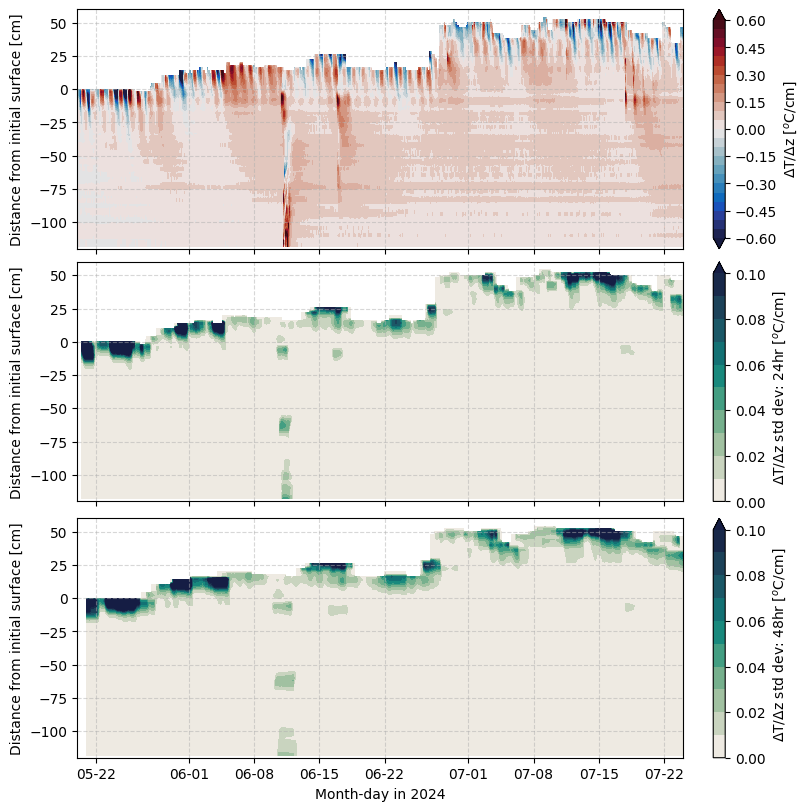

In [57]:
fig, axs = plt.subplots(3, figsize=(8,8), sharey=True, sharex=True, constrained_layout=True)

plt_vars = [simba_dTdz, dTdz_std_24, dTdz_std_48]
plt_labels = ['$\Delta$T/$\Delta$z [$^o$C/cm]', '$\Delta$T/$\Delta$z std dev: 24hr [$^o$C/cm]', '$\Delta$T/$\Delta$z std dev: 48hr [$^o$C/cm]']
plt_cmaps = [cmocean.cm.balance, cmocean.cm.tempo, cmocean.cm.tempo]
plt_levs = [np.arange(-.6,.61,.05), np.arange(0,.11,.01), np.arange(0,.11,.01)]
plt_extends = ['both','max','max']

for i, ax in enumerate(axs.ravel()):
    cb = ax.contourf(simba_dates, simba_depths, np.swapaxes(plt_vars[i],0,1), cmap=plt_cmaps[i], levels=plt_levs[i],
                    extend=plt_extends[i])
    plt.colorbar(cb, ax=ax, label=plt_labels[i])
    
    ax.grid(alpha=.5, ls='--')
    ax.set_ylabel('Distance from initial surface [cm]')

    ax.xaxis.set_major_formatter(myFmt)

axs[0].set_ylim(-120,60)
axs[-1].set_xlabel('Month-day in 2024')
plt.show()

#### Relative to the surface

In [24]:
temps_rel_sfc_std = calc_running_stdev(temps_rel_sfc, window=4*24)

In [29]:
dTdz_rel_sfc_std = calc_running_stdev(dTdz_rel_sfc, window=4*24)

In [37]:
temps_rel_sfc_std_48 = calc_running_stdev(temps_rel_sfc, window=4*48)
dTdz_rel_sfc_std_48 = calc_running_stdev(dTdz_rel_sfc, window=4*48)

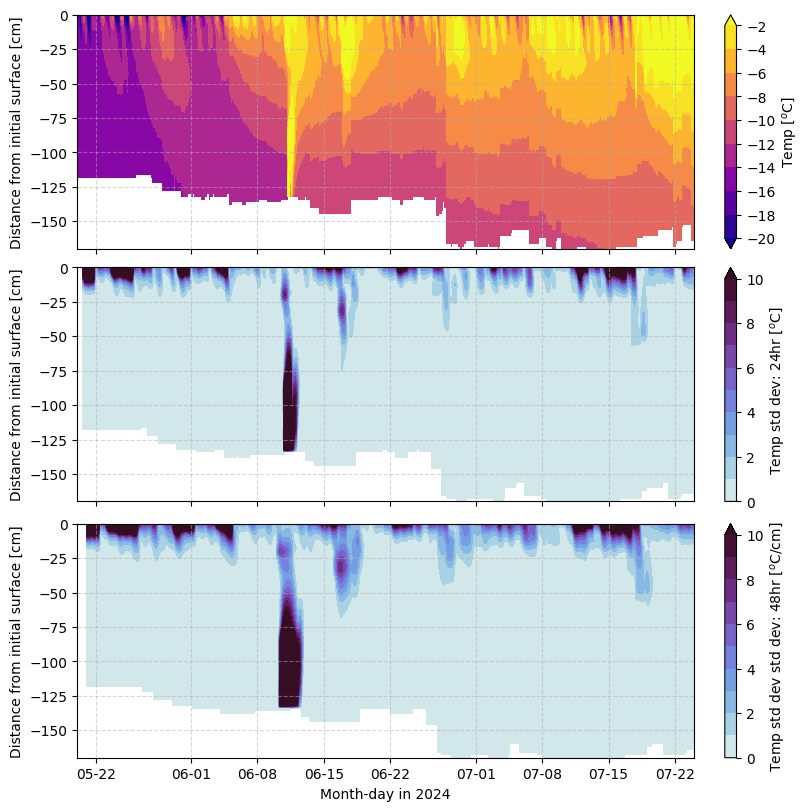

In [48]:
fig, axs = plt.subplots(3, figsize=(8,8), sharey=True, sharex=True, constrained_layout=True)

plt_vars = [temps_rel_sfc, temps_rel_sfc_std, temps_rel_sfc_std_48]
plt_labels = ['Temp [$^o$C]', 'Temp std dev: 24hr [$^o$C]', 'Temp std dev std dev: 48hr [$^o$C/cm]']
plt_cmaps = [plt.cm.plasma, cmocean.cm.dense, cmocean.cm.dense]
plt_levs = [np.arange(-20,0,2), np.arange(0,10.1,1), np.arange(0,10.1,1)]
plt_extends = ['both','max','max']

for i, ax in enumerate(axs.ravel()):
    cb = ax.contourf(simba_dates, depth_rel_sfc, np.swapaxes(plt_vars[i],0,1), cmap=plt_cmaps[i], levels=plt_levs[i],
                    extend=plt_extends[i])
    plt.colorbar(cb, ax=ax, label=plt_labels[i])
    
    ax.grid(alpha=.5, ls='--')
    ax.set_ylabel('Distance from initial surface [cm]')

    ax.xaxis.set_major_formatter(myFmt)

axs[0].set_ylim(-170,0)
axs[-1].set_xlabel('Month-day in 2024')
plt.show()

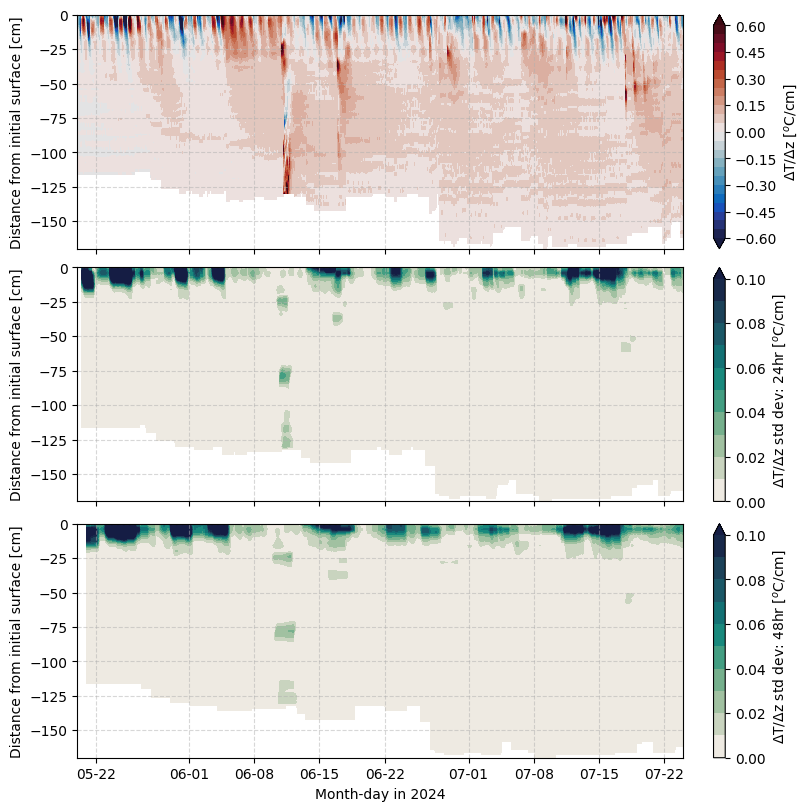

In [47]:
fig, axs = plt.subplots(3, figsize=(8,8), sharey=True, sharex=True, constrained_layout=True)

plt_vars = [dTdz_rel_sfc, dTdz_rel_sfc_std, dTdz_rel_sfc_std_48]
plt_labels = ['$\Delta$T/$\Delta$z [$^o$C/cm]', '$\Delta$T/$\Delta$z std dev: 24hr [$^o$C/cm]', '$\Delta$T/$\Delta$z std dev: 48hr [$^o$C/cm]']
plt_cmaps = [cmocean.cm.balance, cmocean.cm.tempo, cmocean.cm.tempo]
plt_levs = [np.arange(-.6,.61,.05), np.arange(0,.11,.01), np.arange(0,.11,.01)]
plt_extends = ['both','max','max']

for i, ax in enumerate(axs.ravel()): 
    cb = ax.contourf(simba_dates, depth_rel_sfc, np.swapaxes(plt_vars[i],0,1), cmap=plt_cmaps[i], levels=plt_levs[i],
                    extend=plt_extends[i])
    plt.colorbar(cb, ax=ax, label=plt_labels[i])
    
    ax.grid(alpha=.5, ls='--')
    ax.set_ylabel('Distance from initial surface [cm]')

    ax.xaxis.set_major_formatter(myFmt)

axs[0].set_ylim(-170,0)
axs[-1].set_xlabel('Month-day in 2024')
plt.show()

### Recreate old plots relative to the surface

In [58]:
sleigh_vars = ['up_short_hemisp_qc','up_long_hemisp_qc','down_short_hemisp_qc','down_long_hemisp_qc','subsurface_heat_flux_A_qc',
                  'subsurface_heat_flux_B_qc','skin_temp_surface_qc','temp_qc','snow_depth_qc','zenith_true_qc',
                  'down_short_diffuse','down_short_direct','up_short_hemisp','up_long_hemisp','down_short_hemisp','down_long_hemisp',
                  'snow_depth','temp','brightness_temp_surface','skin_temp_surface','subsurface_heat_flux_A','subsurface_heat_flux_B',
                  'subsurface_heat_flux_C','zenith_true','snow_gpr_dist','base_time','time']

asfs_data_lev2 = load_raven_sleigh_data(sleigh_vars)

In [80]:
skin_temp = asfs_data_lev2['skin_temp']
sleigh_dates = asfs_data_lev2['dates']
sleigh_seconds = datetimes_to_seconds(sleigh_dates)

skinT_sfc_timesteps = interpolate_and_mask(skin_temp, sleigh_seconds, simba_seconds)-273.15
skinT_sfc_timesteps = np.ma.masked_outside(skinT_sfc_timesteps, -30, 5)

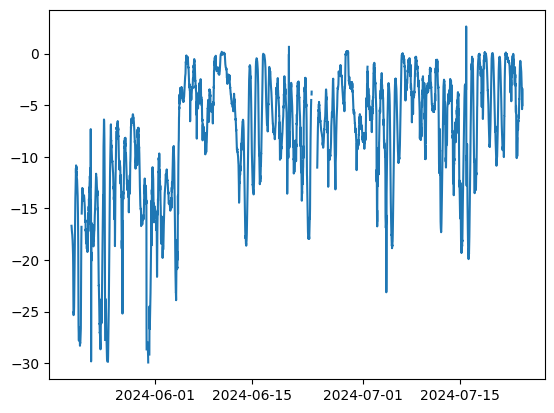

In [81]:
plt.plot(simba_dates, skinT_sfc_timesteps)

In [82]:
temp_corrs = np.ma.corrcoef(temps_rel_sfc[:,0], temps_rel_sfc[:,1:].T)[0][1:]
temp_corrs_skin = np.ma.corrcoef(skinT_sfc_timesteps, temps_rel_sfc[:,:].T)[0][1:]

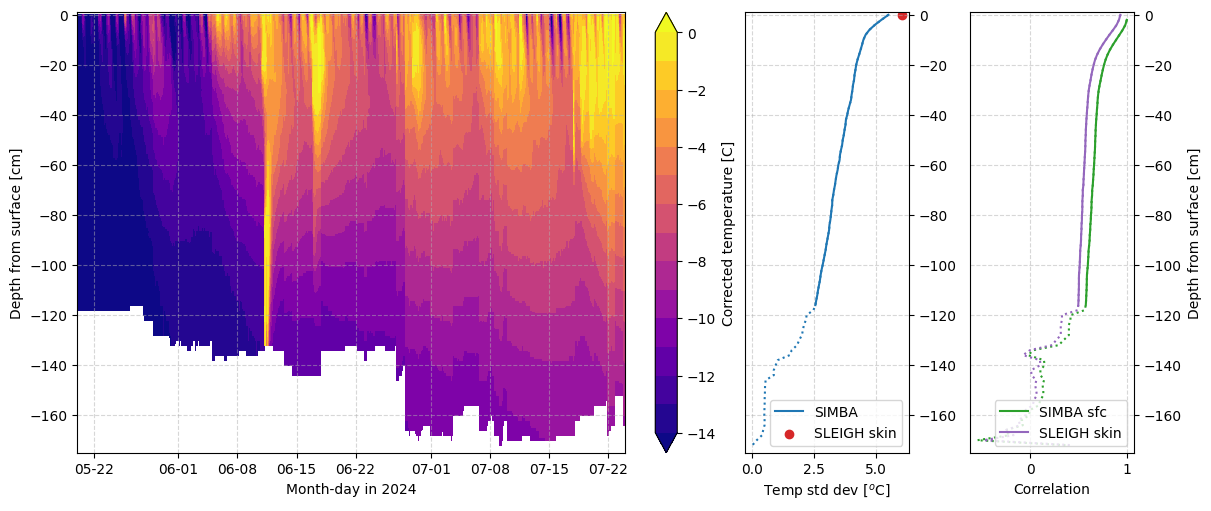

In [88]:


temp_std_profile = temps_rel_sfc.std(axis=0)

## believe that sharp drop in std dev and correlations are due to fewer points than higher up, 
## so show different sections in plot that either have data for every time step or not
temp_counts = temps_rel_sfc.count(axis=0)
l = temps_rel_sfc.count(axis=0)[0]
temp_std_full = np.ma.masked_where(temp_counts<l, temp_std_profile)

fig, axs = plt.subplots(1, 3, figsize=(12,5), gridspec_kw=dict(width_ratios=[4,1.2,1.2]), constrained_layout=True)

cb = axs[0].contourf(simba_dates, depth_rel_sfc, np.swapaxes(temps_rel_sfc,0,1), cmap='plasma',
                    levels=np.arange(-14,0.1,1), extend='both')
plt.colorbar(cb, label='Corrected temperature [C]', ax=axs[0])

axs[1].plot(temp_std_profile, depth_rel_sfc, ls=':', c='tab:blue')

axs[1].plot(temp_std_full, depth_rel_sfc, label='SIMBA', c='tab:blue')

axs[1].scatter(skinT_sfc_timesteps.std(), 0, c='tab:red', label='SLEIGH skin')

axs[1].legend(loc='lower right')

axs[1].set_xlabel('Temp std dev [$^o$C]')

axs[1].yaxis.set_label_position("right")
axs[1].yaxis.tick_right()



axs[2].plot(temp_corrs, depth_rel_sfc[1:],ls=':', c='tab:green')
axs[2].plot(temp_corrs_skin, depth_rel_sfc, ls=':', c='tab:purple')

axs[2].plot(temp_corrs[~temp_std_full[1:].mask], depth_rel_sfc[1:][~temp_std_full[1:].mask], label='SIMBA sfc', c='tab:green')
axs[2].plot(temp_corrs_skin[~temp_std_full.mask], depth_rel_sfc[~temp_std_full.mask], label='SLEIGH skin', c='tab:purple')

axs[2].legend(loc='lower right')

axs[2].set_xlabel('Correlation')

axs[2].yaxis.set_label_position("right")
axs[2].yaxis.tick_right()

axs[0].xaxis.set_major_formatter(myFmt)
axs[0].set_xlabel('Month-day in 2024')

for i, ax in enumerate(axs.ravel()):
    ax.grid(ls='--', alpha=.5)
    ax.set_ylim(-175,1)
    if i!=1:
        ax.set_ylabel('Depth from surface [cm]')

# plt.tight_layout()
# plt.savefig('/home/asledd/ICECAPS/simba_solar_correction_figs/Raven_corrected-simba_20ks_0.5nir_-6sfc_temp-rel-to-sfc_std-dev-depths.png', dpi=250)

plt.show()

In [89]:
def calc_sw_ext(sw_sfc, kappa, depths_in, f_nir=0.5):
    """ swc_sfc is net SW from the atmosphere (SWD-SWU) 
    kappa is snow extinction coefficient, which is going to be used as a tuning parameter
    f_nir is the fraction of SW that is assumed to be NIR (as opposed to visible)
    depths is assumed to be centimeters below the surface with intervals of 2cm, i.e., 2, 4, 6 etc 
    should depths start at 0 or 2? """

    ## so that absorbed SW, clacluated as the difference between levels, covers the temperature
    # depths_in += .01

    ## transmitted SW at each level
    print('SWT shapes',  np.shape(sw_sfc), np.shape(kappa), np.shape(depths_in))
    sw_t = (1-f_nir)*sw_sfc*np.ma.exp(-kappa*np.abs(depths_in))
    print('SWT out shape', sw_t.shape)

    ## absorbed SW at each level
    # indexing will need to change to use SWN timeseries
    sw_a = sw_t[:,:-1] - sw_t[:,1:]

    sfc_sw_a = sw_sfc[:,0]-sw_t[:,1]

    sw_a = np.concatenate((sfc_sw_a[:, np.newaxis], sw_a), axis=1)
    
    return sw_a, sw_t

In [96]:
swn = asfs_data_lev2['net_short_hemisp']
## are very high values real??
swn_sfc_timesteps = np.ma.masked_outside(interpolate_and_mask(swn, sleigh_seconds, simba_seconds), -100, 200)


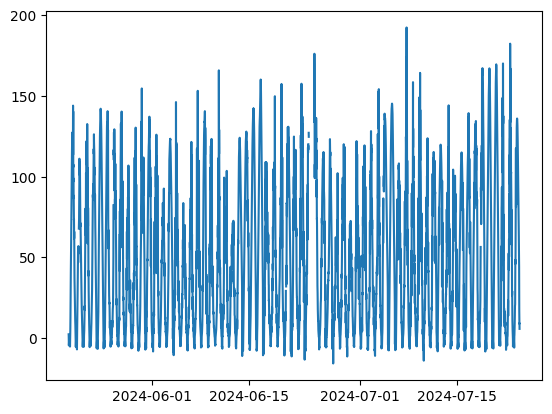

In [97]:
plt.plot(simba_dates, swn_sfc_timesteps)

In [109]:
# make simba heights/depths relative to surface
sfc_height_2d = np.repeat(simba_sfc[:,np.newaxis], depth_rel_sfc.shape[0], axis=1)

# depth_rel_sfc

depth_rel_sfc_m = np.ma.masked_greater(depth_rel_sfc, 0)/100.

simba_swn_2d = np.repeat(swn_sfc_timesteps[:,np.newaxis], sfc_height_2d.shape[1], axis=1)

ks_vis = 15.

    
simba_swa, simba_swt = calc_sw_ext(simba_swn_2d, ks_vis, depth_rel_sfc_m, f_nir=0.5)

SWT shapes (6239, 100) () (100,)
SWT out shape (6239, 100)


In [104]:
simba_swt[simba_swt.mask] = 0.

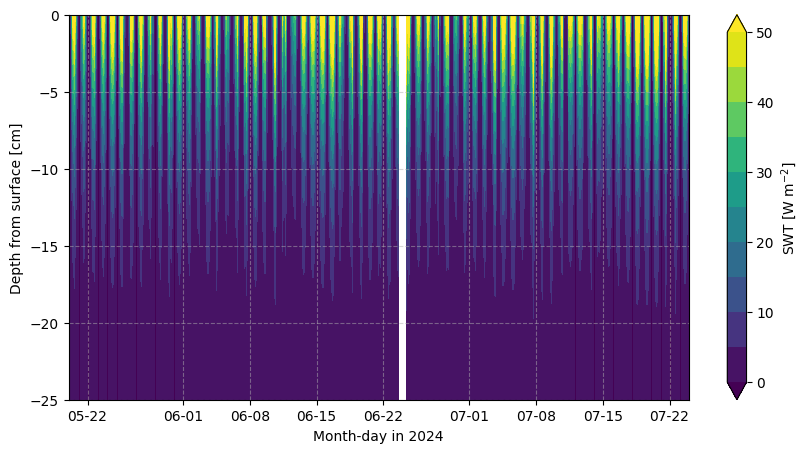

In [117]:
fig, ax = plt.subplots(1, figsize=(10,5))
cb = ax.contourf(simba_dates, depth_rel_sfc, np.swapaxes(simba_swt, 0, 1), levels=np.arange(0,51,5), extend='both')
plt.colorbar(cb, label='SWT [W m$^{-2}$]')
ax.set_ylim(-25,0)
ax.set_ylabel('Depth from surface [cm]')
ax.grid(alpha=.5, ls='--')
ax.xaxis.set_major_formatter(myFmt)
ax.set_xlabel('Month-day in 2024')

plt.show()